<a href="https://colab.research.google.com/github/arthur-craveiro1/calculo-numerico/blob/master/CN_Atividade1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Parte A - Truncamento e Arredondamento

In [10]:
x_1 = 3.14159265
x_2 = 98.76543
x_3 = 0.00498765

casas_decimais = [0,1,2,3,4]
numeros = [x_1,x_2,x_3]

def truncamento(x, n):
  return math.trunc(np.pow(10,n)*x) / np.pow(10,n)

def erro_absoluto(x,x_til):
  return abs(x-x_til)

def erro_relativo(x,x_til):
  return erro_absoluto(x,x_til) / x

def erro_percentual(x,x_til):
  return erro_relativo(x,x_til) * 100


dados = []

for i in numeros:
  for j in casas_decimais:
      truncado = truncamento(i, j)
      arredondado = round(i, j)

      erro_abs_trunc = erro_absoluto(i, truncado)
      erro_rel_trunc = erro_relativo(i, truncado)
      erro_perc_trunc = erro_percentual(i, truncado)

      erro_abs_arred = erro_absoluto(i, arredondado)
      erro_rel_arred = erro_relativo(i, arredondado)
      erro_perc_arred = erro_percentual(i, arredondado)

      dados.append([i, truncado, arredondado, erro_abs_trunc, erro_rel_trunc, erro_perc_trunc,
                    erro_abs_arred, erro_rel_arred, erro_perc_arred])

df = pd.DataFrame(dados, columns=['Número', 'Truncamento', 'Arredondamento',
                                  'Erro Absoluto Truncamento', 'Erro Relativo Truncamento', 'Erro Percentual Truncamento',
                                  'Erro Absoluto Arredondamento', 'Erro Relativo Arredondamento', 'Erro Percentual Arredondamento'])

display(df.head(15))




,Número,Truncamento,Arredondamento,Erro Absoluto Truncamento,Erro Relativo Truncamento,Erro Percentual Truncamento,Erro Absoluto Arredondamento,Erro Relativo Arredondamento,Erro Percentual Arredondamento
0,3.141593,3.0000,3.0000,0.141593,4.507034e-02,4.507034,0.141593,4.507034e-02,4.507034
1,3.141593,3.1000,3.1000,0.041593,1.323935e-02,1.323935,0.041593,1.323935e-02,1.323935
2,3.141593,3.1400,3.1400,0.001593,5.069562e-04,0.050696,0.001593,5.069562e-04,0.050696
3,3.141593,3.1410,3.1420,0.000593,1.886464e-04,0.018865,0.000407,1.296635e-04,0.012966
4,3.141593,3.1415,3.1416,0.000093,2.949141e-05,0.002949,0.000007,2.339578e-06,0.000234
5,98.765430,98.0000,99.0000,0.765430,7.749979e-03,0.774998,0.234570,2.375021e-03,0.237502
6,98.765430,98.7000,98.8000,0.065430,6.624788e-04,0.066248,0.034570,3.500213e-04,0.035002
7,98.765430,98.7600,98.7700,0.005430,5.497875e-05,0.005498,0.004570,4.627125e-05,0.004627
8,98.765430,98.7650,98.7650,0.000430,4.353750e-06,0.000435,0.000430,4.353750e-06,0.000435
9,98.765430,98.7654,98.7654,0.000030,3.037500e-07,0.000030,0.000030,3.037500e-07,0.000030


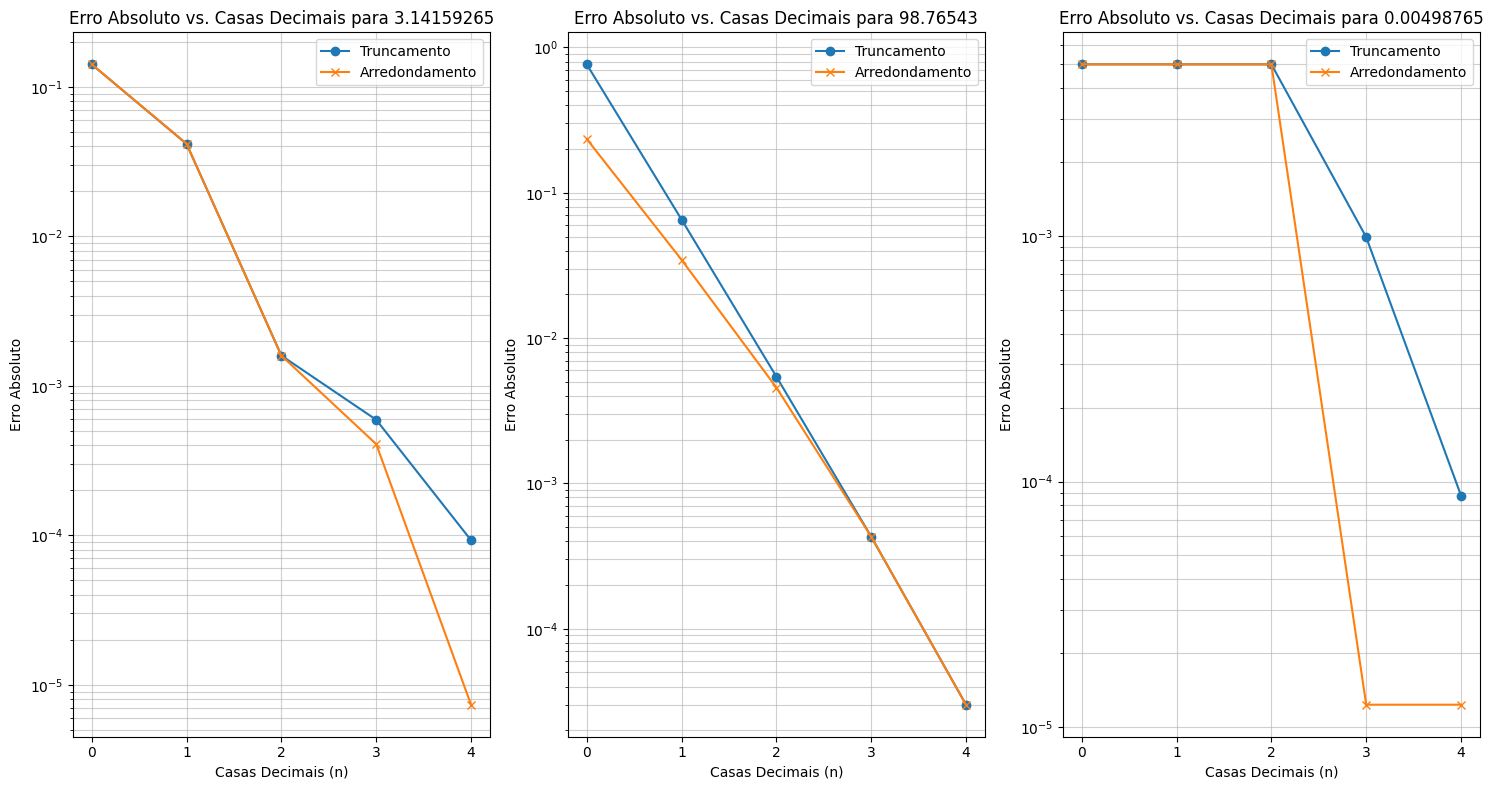

In [11]:
plt.figure(figsize=(15, 8))

for i, numero_original in enumerate(numeros):
    df_filtered = df[df['Número'] == numero_original]

    plt.subplot(1, len(numeros), i + 1) # Create subplots for each original number

    # Plotting for Truncamento
    plt.plot(casas_decimais, df_filtered['Erro Absoluto Truncamento'], marker='o', label='Truncamento')
    # Plotting for Arredondamento
    plt.plot(casas_decimais, df_filtered['Erro Absoluto Arredondamento'], marker='x', label='Arredondamento')

    plt.title(f'Erro Absoluto vs. Casas Decimais para {numero_original}')
    plt.xlabel('Casas Decimais (n)')
    plt.ylabel('Erro Absoluto')
    plt.xticks(casas_decimais)
    plt.yscale('log') # Use log scale for better visualization of small errors
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.6)

plt.tight_layout()
plt.show()

## Questão 5
Arredondar sempre gera erro menor ou igual ao truncamento?

R: Ao arredondar um número, você está escolhendo o número representável mais próximo, o que minimiza a diferença entre o número original e o valor aproximado. No truncamento, você simplesmente descarta os dígitos após um certo ponto, o que sempre move o número em direção a zero e pode resultar em um erro maior se o dígito descartado for 5 ou superior.

Observando os resultados da tabela df e os gráficos gerados, você pode verificar que a coluna 'Erro Absoluto Arredondamento' geralmente apresenta valores menores ou iguais à coluna 'Erro Absoluto Truncamento'. Isso ocorre porque o arredondamento leva em consideração o próximo dígito para fazer uma escolha mais precisa, enquanto o truncamento apenas "corta" o número, independentemente do valor do próximo dígito. Nos casos em que o dígito a ser descartado é menor que 5, o arredondamento pode coincidir com o truncamento (erro igual). Quando o dígito é 5 ou maior, o arredondamento ajusta o último dígito, frequentemente resultando em um erro menor do que se o número fosse simplesmente truncado.

# Parte B

In [21]:
dados_originais = [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]

referencia = np.mean(dados_originais)

dados_arredondados = []
dados_truncados = []

for i in dados_originais:
  dados_arredondados.append(round(i))
  dados_truncados.append(math.trunc(i))

medias = [referencia, np.mean(dados_arredondados), np.mean(dados_truncados)]
desvios = [np.std(dados_originais), np.std(dados_arredondados), np.std(dados_truncados)]
mins = [np.min(dados_originais), np.min(dados_arredondados), np.min(dados_truncados)]
maxs = [np.max(dados_originais), np.max(dados_arredondados), np.max(dados_truncados)]
amplitude = [max - min for max, min in zip(maxs, mins)]

dados = {
    'Média': medias,
    'Desvio Padrão': desvios,
    'Mínimo': mins,
    'Máximo': maxs,
    'Amplitude': amplitude
}



df = pd.DataFrame(dados, index=['Original', 'Arredondado', 'Truncado'])
df['Erro Absoluto'] = df.apply(lambda row: abs(referencia - row['Média']), axis=1)
df['Erro Relativo'] = df.apply(lambda row: (abs(referencia - row['Média'])/row['Média']), axis=1)
df['Erro Percentual (%)'] = df.apply(lambda row: 100*row['Erro Relativo'], axis=1)


display(df)





,Média,Desvio Padrão,Mínimo,Máximo,Amplitude,Erro Absoluto,Erro Relativo,Erro Percentual (%)
Original,121.12,0.790949,119.8,122.4,2.6,0.00,0.000000,0.000000
Arredondado,121.10,0.830662,120.0,122.0,2.0,0.02,0.000165,0.016515
Truncado,120.70,0.900000,119.0,122.0,3.0,0.42,0.003480,0.347970


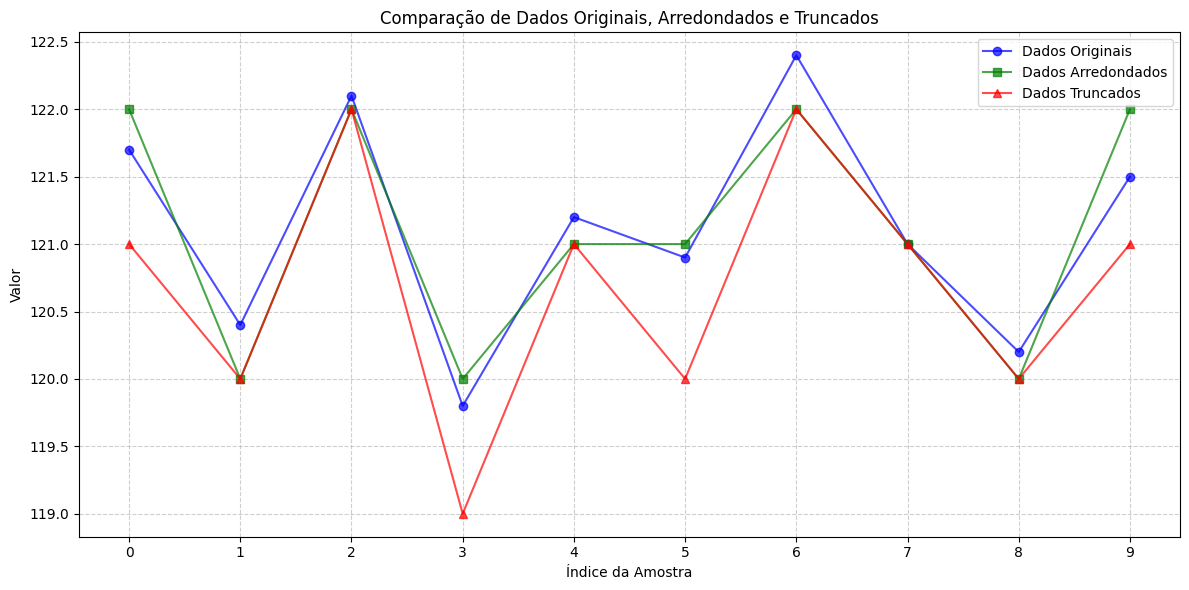

In [26]:
plt.figure(figsize=(12, 6))

# Scatter plot for original data
# plt.scatter(range(len(dados_originais)), dados_originais, color='blue', marker='o', label='Dados Originais', alpha=0.7)
plt.plot(range(len(dados_originais)), dados_originais, color='blue', marker='o', label='Dados Originais', alpha=0.7)

# Scatter plot for rounded data
# plt.scatter(range(len(dados_arredondados)), dados_arredondados, color='green', marker='s', label='Dados Arredondados', alpha=0.7)
plt.plot(range(len(dados_arredondados)), dados_arredondados, color='green', marker='s', label='Dados Arredondados', alpha=0.7)

# Scatter plot for truncated data
# plt.scatter(range(len(dados_truncados)), dados_truncados, color='red', marker='^', label='Dados Truncados', alpha=0.7)
plt.plot(range(len(dados_truncados)), dados_truncados, color='red', marker='^', label='Dados Truncados', alpha=0.7)


plt.title('Comparação de Dados Originais, Arredondados e Truncados')
plt.xlabel('Índice da Amostra')
plt.ylabel('Valor')
plt.xticks(range(len(dados_originais))) # Show all indices on x-axis
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1434/197491029.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=error_data.index, y=error_data.values, palette='viridis')


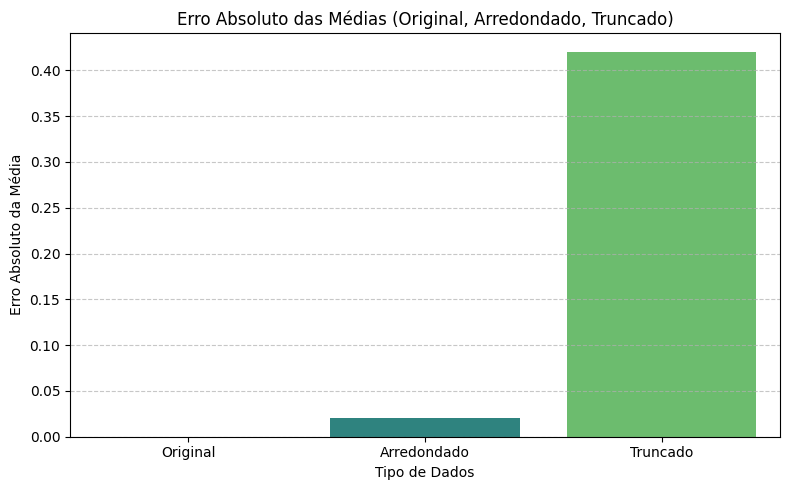

In [29]:
plt.figure(figsize=(8, 5))

# Get the 'Erro Absoluto' for 'Original', 'Arredondado', 'Truncado'
error_data = df.loc[['Original', 'Arredondado', 'Truncado'], 'Erro Absoluto']

sns.barplot(x=error_data.index, y=error_data.values, palette='viridis')

plt.title('Erro Absoluto das Médias (Original, Arredondado, Truncado)')
plt.xlabel('Tipo de Dados')
plt.ylabel('Erro Absoluto da Média')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1434/2610202788.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=percent_error_data.index, y=percent_error_data.values, palette='plasma')


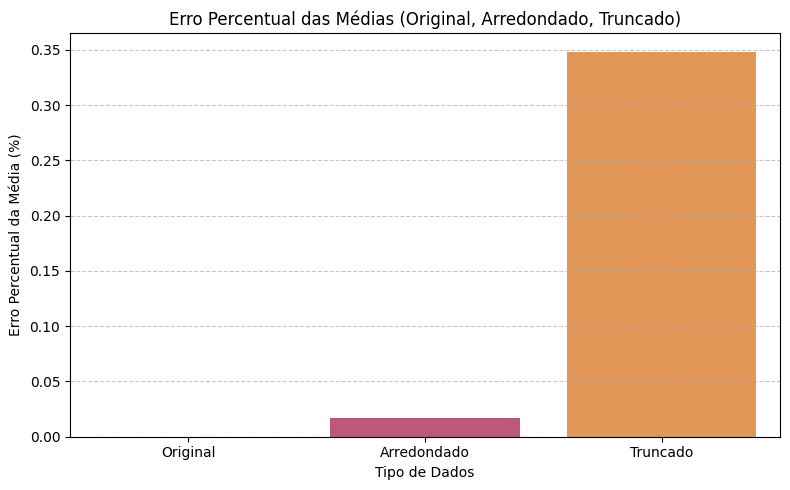

In [30]:
plt.figure(figsize=(8, 5))

# Get the 'Erro Percentual (%)' for 'Original', 'Arredondado', 'Truncado'
percent_error_data = df.loc[['Original', 'Arredondado', 'Truncado'], 'Erro Percentual (%)']

sns.barplot(x=percent_error_data.index, y=percent_error_data.values, palette='plasma')

plt.title('Erro Percentual das Médias (Original, Arredondado, Truncado)')
plt.xlabel('Tipo de Dados')
plt.ylabel('Erro Percentual da Média (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

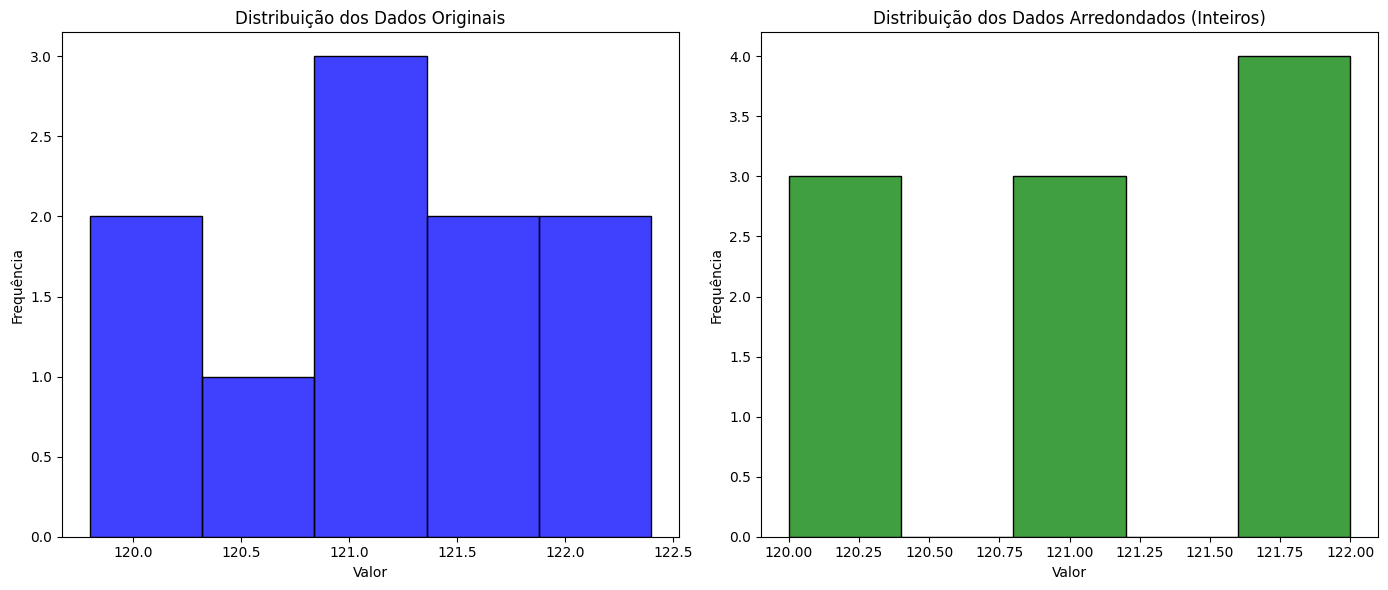

In [34]:
plt.figure(figsize=(14, 6))

# Histograma para Dados Originais
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(dados_originais, kde=False, color='blue', bins=5)
plt.title('Distribuição dos Dados Originais')
plt.xlabel('Valor')
plt.ylabel('Frequência')

# Histograma para Dados Arredondados
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(dados_arredondados, kde=False, color='green', bins=5)
plt.title('Distribuição dos Dados Arredondados (Inteiros)')
plt.xlabel('Valor')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

A média da amostra original é de 121.12, enquanto que a média dos dados arredondados é 121.10 e truncados é 120.70. Podemos ver que  o erro percentual de ambos os arredondamentos é bem pequeno(0.0165% e 0.3480%). Portanto, podemos considerar que a representação inteira preserva sim a média dos dados. No entando, a representação inteira afeta bem mais a variabilidade em comparação aos dados originais. Podemos perceber isto observando os histogramas: os dados arredondados, por terem menos espaço para variação, diminuem a variabilidade geral dos dados, mostrado pelas barras bem próximas uma das outras.